In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from utils.abcd import M_free, M_focal, stability_condition, eigen_q, waist_and_position

# Propagation matrices

We define below the propagation matrices for different cavities configurations:
- linear cavity (concave-concave, planoconcave)
- circular cavity (bow-tie ring)

### Linear cavities

In [3]:
def concave_concave(roc1, roc2, L, l_crystal, index):
    """
    Linear cavity formed by two curved mirrors
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2
    # Geometrical length of propagation in the air
    l_air = L - l_crystal

    # Propagation matrix (starts from mirror 1)
    M = M_focal(f1) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2) @ M_focal(f2) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2)

    return M

In [4]:
def plano_concave(roc, L, l_crystal, index):
    """
    Linear cavity formed by a curved mirror and a flat mirror.
    Same calculation as concave-concave, but with a roc2 = infty
    :param roc: radius of curvature of mirror
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    roc2 = np.inf
    return concave_concave(roc1=roc, roc2=roc2, L=L, l_crystal=l_crystal, index=index)

### Ring cavity

In [5]:
def bow_tie(roc1, roc2, L, d_curved, l_crystal, index):
    """
    Bow tie ring cavity
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param d_curved: distance between the curved mirrors
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2

    # Geometrical length of propagation in the air
    l1 = (L - d_curved) / 2  # L = d_curved + d_flat + 2*d_diag
    l2 = (d_curved - l_crystal) / 2

    # Propagation matrix (starts from middle of flat mirrors)
    M = M_free(l1) @ M_focal(f2) @ M_free(l2) @ M_free(l_crystal/index) @ M_free(l2) @ M_focal(f1) @ M_free(l1)

    return M

# Cavity design

We aim at defining cavity designs based on our experiment constraints (namely finesse and bandwidth).
The idea is to define a "sweep" parameter (cavity length $L$, RoC, etc.) and identify the stability region if it exists. Then based on where the $q_0$ parameter has been chosen, we define a full propagation $q$ parameter over the full cavity to find its waist. For the planoconcave cavity, since the waist is located on the flat mirror, we need to find the position of a target waist instead.

In [6]:
wavelength = 780e-9  # 780 nm

In [7]:
l_crystal = 20e-3  # 20 mm
index = 1.84

In [8]:
roc1 = 100e-3  # 100 mm
roc2 = 150e-3  # 100 mm

### Linear cavities

In [9]:
L_linear = np.linspace(start=0, stop=300, num=600, endpoint=True) * 1e-3  # from 0 to 300 mm

In [13]:
waist_values = []
z_waist_values = []

for L in L_linear:
    # Propagation matrix
    M = concave_concave(roc1=roc1, roc2=roc1, L=L, l_crystal=l_crystal, index=index)

    # Compute q parameter at origin of propagation (M1)
    q0 = eigen_q(M)

    if q is None:
        continue
    # Propagation along z axis over cavity length
    z_propagation = np.linspace(start=0, stop=L, num=1000)
    q_propagation = q0 + z_propagation

    # Compute the waist profile along the cavity
    w, z = waist_and_position(q_propagation, wavelength)
    # Find the waist and its position
    i0 = np.argmin(w)
    w0 = w[i0]
    z0 = z[i0]

    waist_values.append(w0)
    z_waist_values.append(z0)

In [14]:
waists = np.array(waist_values)
z_waists = np.array(z_waist_values)

ValueError: x and y must have same first dimension, but have shapes (600,) and (0,)

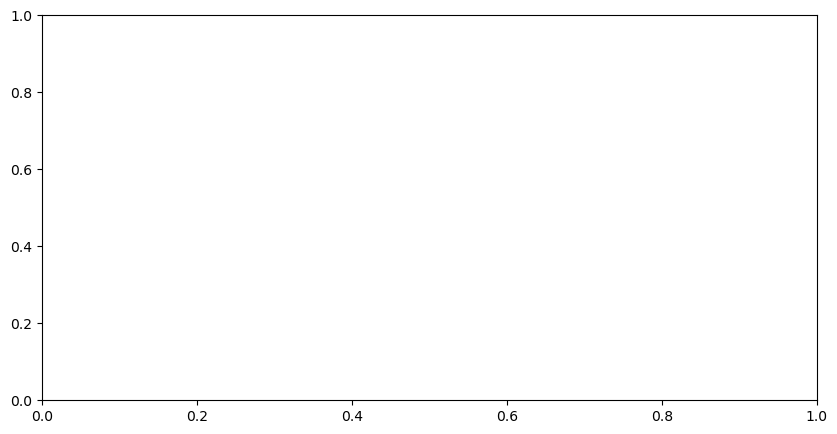

In [15]:
# Plot the waist as a function of the cavity length
plt.figure(figsize=(10, 5))
plt.plot(L_linear, waists, label="Waist")
plt.xlabel("Cavity Length (mm)")
plt.ylabel("Waist (mm)")
plt.title("Waist as a function of cavity length")
plt.legend()
plt.show()